# Processing human results

In [6]:
import pandas as pd

## Identifying missing IDs

In [7]:
data = pd.read_csv('CreativityEval_2026_05_04_10_38.csv')

In [30]:
done_ids = data['assignment_id'].copy()
done_ids = done_ids.iloc[2:].to_list()
done_ids_int = set([int(elem) for elem in done_ids])
int_set = set(range(60))
missing_ids = int_set - done_ids_int

In [37]:
missing_ids

{17, 26, 28, 48, 49, 55, 57, 58, 59}

In [40]:
initial_assignment = pd.read_csv('../assignments_sheets.csv', index_col='assignment_id')
re_assignment = initial_assignment.iloc[list(missing_ids)]
re_assignment.to_csv("assignments_sheets_missing_ids.csv")

## Reworking qualtrics format to useable format

In [2]:
from collections import defaultdict
import json
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Criteria mapping
criteria_mapping = {
	0 : 'grammaticaliteit',
	1 : 'coherentie',
	2 : 'orginaliteit',
	3 : 'creativiteit',
	4 : 'complexiteit',
	5 : 'plezier',
	6 : 'menselijkheid'
}

In [8]:
# You did not re-index after selecting so you have indices up to 210 instead of 200
# Some rows are suppose to stay empty --> ids: 30, 53, 78, 82, 102, 105, 107, 142, 144, 161
judge_reliability = []
nan_attempts = []
scores = np.zeros((210, 7, 3)) # (stories, criteria, judges)

for r, row in data[2:].iterrows(): # per participant
	mistake_counter = 0
	selected_stories = json.loads(row['selected_stories'])

	for i, info in enumerate(selected_stories): # per story
		likertQ_id = i + 1
		id = info['id']

		try:
			mistake_counter += int(row[f'incorrect_attempts_{likertQ_id}'])
		except:
			pass

		for criterium in criteria_mapping.keys(): # per criteria
			likertQ_value = int(row[f'{likertQ_id}_Likert_{criterium + 1}']) # likert scale starts from 1
			no_judges = np.where(scores[id, criterium] == 0)[0][0]
			scores[id, criterium, no_judges] = likertQ_value
	judge_reliability.append(mistake_counter)

Text(0.5, 1.0, 'Amount of mistakes over 10 questions (max. 20)')

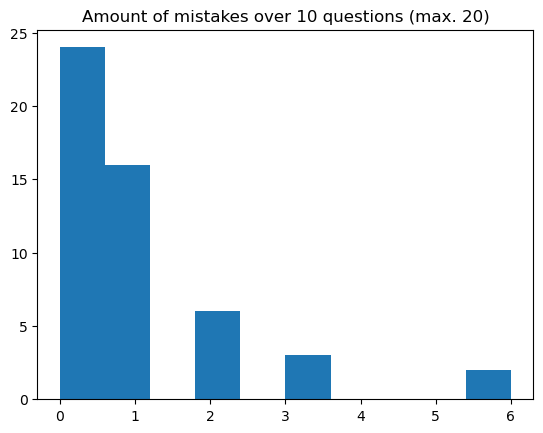

In [9]:
plt.hist(judge_reliability)
plt.title('Amount of mistakes over 10 questions (max. 20)')